In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

from pathlib import Path
from tqdm import tqdm

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils.config import load_config
from src.utils.scale import unscale_masses
from src.validation import get_tpcf

### Helpers and Functions

In [2]:
WIDTH_LATEX = 4.9
FONT_COLOR = "0" # or "#0E1D35" for the dark blue as per pp theme

In [3]:
def find_equally_spaced_indices(arr, n):
    "Based on specific conditioning parameter."
    sorted_indices = np.argsort(arr)
    sorted_arr = arr[sorted_indices]
    min_val, max_val = sorted_arr[0], sorted_arr[-1]
    division_points = np.linspace(min_val, max_val, n)
    closest_indices = np.searchsorted(sorted_arr, division_points)
    closest_indices = np.clip(closest_indices, 0, len(arr) - 1)
    original_indices = sorted_indices[closest_indices]
    return original_indices

In [4]:
#### Calculate 2pcf for sampled
def calc_tpcf_gen(gen_list, scale=True):
    """
    gen array must have size: # cosmology, # repeats, # particles, 3
    """
    gen_tpcf = []
    for i in tqdm(range(len(gen_list))):     # Loop over cosmologies
        inter_gen_tpcf = []
        samples = gen_list[i].squeeze(0)
        for j in range(samples.shape[0]):    # Loop over number of repeats for cosmology
            s = samples[j] * 370 if scale == True else samples[j]
            inter_gen_tpcf.append(get_tpcf(s, boxsize, r_bins, mu_bins))
        gen_tpcf.append(np.array(inter_gen_tpcf))
    gen_tpcf = np.array(gen_tpcf)
    return gen_tpcf

In [5]:
#### Calculate MAE
def calc_mae(sim_tpcf, gen_tpcf):
    
    mae = np.mean(np.absolute(sim_tpcf[:, None] - gen_tpcf), axis=(0, 1))
    mae_total = np.mean(mae)
    print("mae:", mae)
    print("mae total:", mae_total)

    return mae, mae_total

In [6]:
#### Calculate MSE 
def calc_mse(sim_tpcf, gen_tpcf):
    mse = np.mean((sim_tpcf[:, None] - gen_tpcf)**2, axis=(0, 1))
    mse_total = np.mean(mse)
    print("mse:", mse)
    print("mse total:", mse_total)

    return mse, mse_total

In [7]:
def remove_padding(sample, halo_counts, idx):
    halo_count = halo_counts[idx]
    unpadded_sample = sample[:halo_count]
    return unpadded_sample

### Data Loading and Preprocessing

In [8]:
# Two-Point Correlation function
boxsize = 370.
r_bins = np.linspace(0.5, 150.0, 25) # Defines 25 linearly spaced bins from 0.5 to 150 for the radial separation r
r_c = 0.5*(r_bins[1:] + r_bins[:-1]) # Computes the center of each radial bin (midpoint between two consecutive bins)
mu_bins = np.linspace(-1, 1, 201)

In [9]:
# In and Out Directories
train_run = "20260514_113408"
infer_run = "20260514_145244"
config_dir = f"/gpfs/home4/bartb/FlowEGNN/T256/results/run_{train_run}/qualitative_2pcf/{infer_run}/final_config.yaml"
config = load_config(config_dir)
output_dir = os.path.dirname(config_dir)

In [10]:
# Load true and generated samples
gen_samples = torch.load(f"/gpfs/home4/bartb/FlowEGNN/T256/results/run_{train_run}/qualitative_2pcf/{infer_run}/gen_samples.pth", weights_only=False)#.squeeze(0)
# print(f"Shape of generated samples: {gen_samples.shape}")

true_samples = torch.from_numpy(np.load("/gpfs/home4/bartb/FlowEGNN/Data/subboxes/test_subbox_halos.npy")[..., :3])
print(f"Shape of true samples: {true_samples.shape}")

halo_counts = np.load("/gpfs/home4/bartb/FlowEGNN/Data/subboxes/test_subbox_counts.npy")
print(f"Shape of subbox counts: {halo_counts.shape}")

Shape of true samples: torch.Size([1887, 320, 3])
Shape of subbox counts: (1887,)


In [11]:
# Load parameters
params = pd.read_csv("/gpfs/home4/bartb/FlowEGNN/Data/subboxes/test_cosmology.csv").values
print(f"Shape of parameters: {params.shape}")

Shape of parameters: (1887, 5)


In [12]:
### equally spaced based on Omega_m! : conditioning[:, 0]
equally_spaced = 20
params_idx_used = find_equally_spaced_indices(params[:,0], equally_spaced)
params_used = params[params_idx_used]
params_used = params_used[::4]

eval_cosm = params_used
n_eval = eval_cosm.shape[0]

print(f"Selected {n_eval} cosmologies:")
print(eval_cosm)
# true_samples_used = true_samples[params_idx_used][ :, :, :3] / 370 # normalize coordinates
# print(f"Shape of true samples used: {true_samples_used.shape}")
    

Selected 5 cosmologies:
[[0.1001  0.05047 0.8959  1.0103  0.9203 ]
 [0.1839  0.04711 0.8675  1.0421  0.6845 ]
 [0.2683  0.03749 0.7533  0.9845  0.9205 ]
 [0.3539  0.06139 0.6681  0.8327  0.6243 ]
 [0.4365  0.06281 0.7347  1.0699  0.9509 ]]


In [13]:
cosm_tol = 1e-4  
 
subbox_indices_per_cosm = []
mean_halo_counts = []
 
for i in range(n_eval):
    diffs = np.abs(params - eval_cosm[i])
    matches = np.all(diffs < cosm_tol, axis=1)
    indices = np.where(matches)[0]
    subbox_indices_per_cosm.append(indices)
 
    counts = halo_counts[indices]
    mean_count = int(np.round(np.mean(counts)))
    mean_halo_counts.append(mean_count)
 
    print(f"Cosm {i} (Ωm={eval_cosm[i,0]:.4f}, σ8={eval_cosm[i,4]:.4f}): "
          f"{len(indices)} subboxes, counts={counts.tolist()}, mean={mean_count}")

Cosm 0 (Ωm=0.1001, σ8=0.9203): 4 subboxes, counts=[308, 212, 310, 293], mean=281
Cosm 1 (Ωm=0.1839, σ8=0.6845): 10 subboxes, counts=[218, 252, 248, 246, 258, 263, 264, 252, 250, 265], mean=252
Cosm 2 (Ωm=0.2683, σ8=0.9205): 10 subboxes, counts=[213, 241, 237, 229, 234, 242, 287, 203, 235, 227], mean=235
Cosm 3 (Ωm=0.3539, σ8=0.6243): 10 subboxes, counts=[282, 288, 296, 240, 270, 273, 248, 237, 246, 265], mean=264
Cosm 4 (Ωm=0.4365, σ8=0.9509): 10 subboxes, counts=[238, 265, 227, 241, 290, 251, 213, 224, 251, 297], mean=250


In [14]:
tcpf_true_avg = []
tcpf_true_std = []
 
for i in range(n_eval):
    indices = subbox_indices_per_cosm[i]
    tpcfs = []
    for idx in indices:
        n_halos = halo_counts[idx]
        sample = true_samples[idx, :n_halos, :3].numpy()
        tpcf = get_tpcf(sample, boxsize, r_bins, mu_bins)
        tpcfs.append(tpcf)
 
    tpcfs = np.array(tpcfs)
    tcpf_true_avg.append(np.mean(tpcfs, axis=0))
    tcpf_true_std.append(np.std(tpcfs, axis=0))
 
tcpf_true_avg = np.array(tcpf_true_avg)  # (n_eval, n_rbins)
tcpf_true_std = np.array(tcpf_true_std)
 
print(f"\nAveraged GT 2PCF shape: {tcpf_true_avg.shape}")
for i in range(n_eval):
    print(f"  Cosm {i}: averaged over {len(subbox_indices_per_cosm[i])} subboxes")

/home/bartb/venvs/boids/lib/python3.11/site-packages/pycorr/corrfunc.py:153: UserWarning: These arguments are not read: {'n_threads': 2}
  warnings.warn('These arguments are not read: {}'.format(attrs))



Averaged GT 2PCF shape: (5, 24)
  Cosm 0: averaged over 4 subboxes
  Cosm 1: averaged over 10 subboxes
  Cosm 2: averaged over 10 subboxes
  Cosm 3: averaged over 10 subboxes
  Cosm 4: averaged over 10 subboxes


In [15]:
print("\nMean halo counts per cosmology:")
for i in range(n_eval):
    print(f"  Cosm {i} (Ωm={eval_cosm[i,0]:.4f}): n_halos = {mean_halo_counts[i]}")


Mean halo counts per cosmology:
  Cosm 0 (Ωm=0.1001): n_halos = 281
  Cosm 1 (Ωm=0.1839): n_halos = 252
  Cosm 2 (Ωm=0.2683): n_halos = 235
  Cosm 3 (Ωm=0.3539): n_halos = 264
  Cosm 4 (Ωm=0.4365): n_halos = 250


In [16]:
n_repeats = config["inference"]["n_repeats"]
print(f"n_cosmologies={n_eval}, n_repeats={n_repeats}")
 
tcpf_gen = calc_tpcf_gen(gen_samples, scale=True)
print(f"Generated 2PCF shape: {tcpf_gen.shape}")

n_cosmologies=5, n_repeats=20


100%|██████████| 5/5 [00:00<00:00,  8.23it/s]

Generated 2PCF shape: (5, 20, 24)


In [17]:
mae, mae_total = calc_mae(tcpf_true_avg, tcpf_gen)
mse, mse_total = calc_mse(tcpf_true_avg, tcpf_gen)

mae: [4.60042381 1.18115441 0.51518085 0.30633275 0.30525985 0.19768649
 0.12445243 0.12572716 0.10641534 0.07986986 0.07871841 0.05995689
 0.06651997 0.05843844 0.0646347  0.05989076 0.06858011 0.1030286
 0.06383677 0.04692954 0.03703624 0.0352027  0.03036316 0.03172641]
mae total: 0.3478069024071682
mse: [3.32563643e+01 2.09713912e+00 4.30358625e-01 1.64055472e-01
 1.59716741e-01 6.16751601e-02 2.70543791e-02 2.36316563e-02
 1.80637535e-02 9.51029913e-03 1.02005686e-02 5.81135994e-03
 7.21315922e-03 5.40623440e-03 7.22227017e-03 5.64656996e-03
 8.29995151e-03 1.53340918e-02 8.32958821e-03 3.49861355e-03
 2.19362375e-03 1.81361258e-03 1.58664232e-03 1.61637498e-03]
mse total: 1.5138225908744622


### Plots

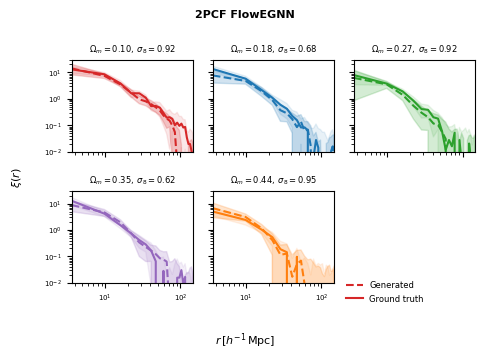

In [18]:
# ============================================================
# Cell: 2PCF subplot — one panel per cosmology (3×2 grid)
# ============================================================

colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']

fig, axes = plt.subplots(2, 3, figsize=(WIDTH_LATEX, 3.5), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i in range(n_eval):
    ax = axes_flat[i]
    
    gen_mean = np.mean(tcpf_gen[i], axis=0)
    gen_std  = np.std(tcpf_gen[i], axis=0)

    # Generated: dashed + band
    ax.fill_between(r_c, gen_mean - gen_std, gen_mean + gen_std,
                    alpha=0.2, color=colors[i])
    ax.plot(r_c, gen_mean, linestyle='--', color=colors[i], label='Generated')

    # Ground truth: solid + band
    ax.plot(r_c, tcpf_true_avg[i], color=colors[i], label='Ground truth')
    ax.fill_between(r_c,
                    tcpf_true_avg[i] - tcpf_true_std[i],
                    tcpf_true_avg[i] + tcpf_true_std[i],
                    alpha=0.1, color=colors[i])

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-2, 30)
    ax.set_xlim(r_c[0], r_c[-1])
    ax.set_title(rf'$\Omega_m={eval_cosm[i,0]:.2f},\;\sigma_8={eval_cosm[i,4]:.2f}$',
                 fontsize=6, color=FONT_COLOR)
    ax.tick_params(which='both', labelsize=5)

# Hide the 6th (empty) subplot
axes_flat[5].set_visible(False)

# Shared axis labels
fig.supxlabel(r"$r\,[h^{-1}\,{\rm Mpc}]$", fontsize=8, color=FONT_COLOR)
fig.supylabel(r'$\xi(r)$', fontsize=8, color=FONT_COLOR)

# Single legend from first panel
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=6, framealpha=0,
           bbox_to_anchor=(0.88, 0.12))

fig.suptitle("2PCF FlowEGNN", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.show()

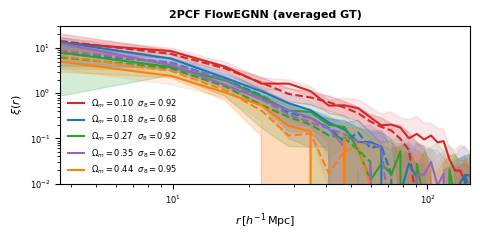

In [19]:
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']
 
fig, ax = plt.subplots(figsize=(WIDTH_LATEX, 2.5))
 
for i in range(n_eval):
    gen_mean = np.mean(tcpf_gen[i], axis=0)
    gen_std  = np.std(tcpf_gen[i], axis=0)
 
    # Generated: dashed + shaded band
    ax.fill_between(r_c, gen_mean - gen_std, gen_mean + gen_std,
                    alpha=0.2, color=colors[i])
    ax.plot(r_c, gen_mean, linestyle='--', color=colors[i])
 
    # Ground truth: solid + thin band showing subbox variance
    ax.plot(r_c, tcpf_true_avg[i], color=colors[i],
            label=rf'$\Omega_m = {eval_cosm[i,0]:.2f} \,\,\,\, \sigma_8 = {eval_cosm[i,4]:.2f}$')
    ax.fill_between(r_c,
                    tcpf_true_avg[i] - tcpf_true_std[i],
                    tcpf_true_avg[i] + tcpf_true_std[i],
                    alpha=0.1, color=colors[i])
 
ax.set_title("2PCF FlowEGNN (averaged GT)", fontsize=8, fontweight="bold")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-2, 30)
ax.set_xlim(r_c[0], r_c[-1])
ax.set_ylabel(r'$\xi(r)$', color=FONT_COLOR, fontsize=8)
ax.set_xlabel(r"$r\,[h^{-1}\,{\rm Mpc}]$", color=FONT_COLOR, fontsize=8)
ax.tick_params(colors=FONT_COLOR, which='both', labelsize=6)
ax.legend(labelcolor=FONT_COLOR, fontsize=6, loc='lower left', framealpha=0)
plt.tight_layout()
plt.show()

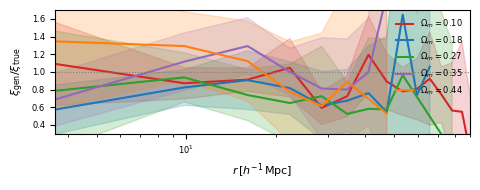

In [20]:
fig, ax = plt.subplots(figsize=(WIDTH_LATEX, 2.0))
 
for i in range(n_eval):
    gen_mean = np.mean(tcpf_gen[i], axis=0)
    gen_std  = np.std(tcpf_gen[i], axis=0)
 
    # Only where GT is above noise floor
    valid = tcpf_true_avg[i] > 0.05
    ratio = gen_mean[valid] / tcpf_true_avg[i][valid]
    ratio_err = gen_std[valid] / tcpf_true_avg[i][valid]
 
    ax.fill_between(r_c[valid], ratio - ratio_err, ratio + ratio_err,
                    alpha=0.2, color=colors[i])
    ax.plot(r_c[valid], ratio, color=colors[i],
            label=rf'$\Omega_m = {eval_cosm[i,0]:.2f}$')
 
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xscale('log')
ax.set_ylim(0.3, 1.7)
ax.set_xlim(r_c[0], 90)  # truncate at ~L/4
ax.set_ylabel(r'$\xi_{\rm gen} / \xi_{\rm true}$', fontsize=8)
ax.set_xlabel(r"$r\,[h^{-1}\,{\rm Mpc}]$", fontsize=8)
ax.tick_params(which='both', labelsize=6)
ax.legend(fontsize=6, loc='upper right', framealpha=0)
plt.tight_layout()
plt.show()

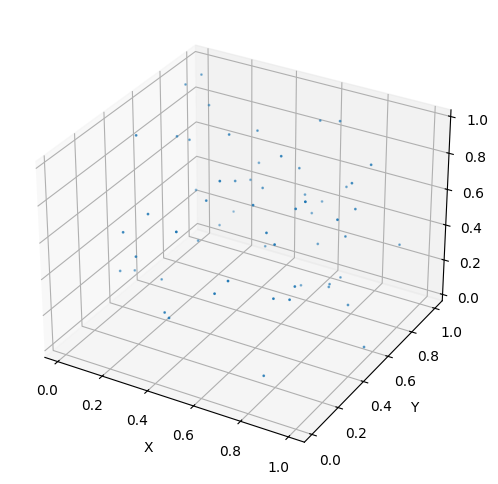

In [21]:
# Visualization of a generated sample
halos = gen_samples[0][0]
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(halos[:, 0], halos[:, 1], halos[:, 2], s=1)


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")


plt.show()


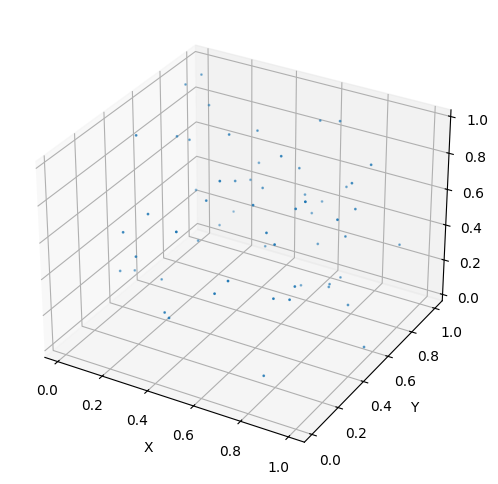

In [22]:
# Visualization of a generated sample
padded_halos = true_samples[0]
unpadded_halos = remove_padding(padded_halos, halo_counts, params_idx_used[::4][0])
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")


ax.scatter(halos[:, 0], halos[:, 1], halos[:, 2], s=1)


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")


plt.show()

### Halo mass function (HMF)

In [23]:
gen_masses = torch.load(f"/gpfs/home4/bartb/T256/T256-SUBBOX/results/run_{train_run}/qualitative_2pcf/{infer_run}/gen_masses.pth", weights_only=False)
print(f"Number of cosmologies: {len(gen_masses)}")

FileNotFoundError: [Errno 2] No such file or directory: '/gpfs/home4/bartb/T256/T256-SUBBOX/results/run_20260514_113408/qualitative_2pcf/20260514_145244/gen_masses.pth'

In [ ]:
# Compute average hmf for ground truth
mass_bins = np.linspace(13.5, 16.5, 50)
box_volume = 370.**3  # (h^-1 Mpc)^3

hmf_true_avg = []
hmf_true_std = []

for i in range(n_eval):
    indices = subbox_indices_per_cosm[i]
    hmfs = []
    for idx in indices:
        n_h = halo_counts[idx]
        # Column 6 in the full data is mass — check your data format
        raw_masses = np.load("/gpfs/home4/bartb/T256/Data/subboxes/test_subbox_halos.npy",
                            mmap_mode='r')[idx, :n_h, 6]
        log10_masses = np.log10(raw_masses)
        # Cumulative: n(> M)
        cumulative = np.array([np.sum(log10_masses > m) for m in mass_bins]) / box_volume
        hmfs.append(cumulative)
    
    hmfs = np.array(hmfs)
    hmf_true_avg.append(np.mean(hmfs, axis=0))
    hmf_true_std.append(np.std(hmfs, axis=0))

hmf_true_avg = np.array(hmf_true_avg)
hmf_true_std = np.array(hmf_true_std)

In [ ]:
# Compute hmf for generated samples
hmf_gen_all = []
for i in range(n_eval):
    masses_i = gen_masses[i].squeeze(0)  # (n_repeats, n_halos_i, 1)
    hmfs = []
    for j in range(masses_i.shape[0]):
        m_scaled = masses_i[j, :, 0]
        log10_masses = unscale_masses(m_scaled)
        cumulative = np.array([np.sum(log10_masses > m) for m in mass_bins]) / box_volume
        hmfs.append(cumulative)
    hmf_gen_all.append(np.array(hmfs))

In [ ]:
# Plot cumulative hmf
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']

fig, ax = plt.subplots(figsize=(WIDTH_LATEX, 2.5))

for i in range(n_eval):
    gen_mean = np.mean(hmf_gen_all[i], axis=0)
    gen_std  = np.std(hmf_gen_all[i], axis=0)
    
    # Generated: dashed + band
    ax.plot(mass_bins, gen_mean, linestyle='--', color=colors[i])
    ax.fill_between(mass_bins, gen_mean - gen_std, gen_mean + gen_std,
                    alpha=0.2, color=colors[i])
    
    # Ground truth: solid + thin band
    ax.plot(mass_bins, hmf_true_avg[i], color=colors[i],
            label=rf'$\Omega_m = {eval_cosm[i,0]:.2f} \,\,\,\, \sigma_8 = {eval_cosm[i,4]:.2f}$')
    ax.fill_between(mass_bins,
                    hmf_true_avg[i] - hmf_true_std[i],
                    hmf_true_avg[i] + hmf_true_std[i],
                    alpha=0.1, color=colors[i])

ax.set_xscale('linear')  # already in log10 space
ax.set_yscale('log')     # y-axis still log since it's counts/volume
ax.set_xlabel(r'$\log_{10}(M_{\rm halo} / h^{-1} M_\odot)$', fontsize=8)
ax.set_ylabel(r'$n(>M_{\rm halo})$', fontsize=8)
ax.set_title('Cumulative Halo Mass Function', fontsize=8, fontweight='bold')
ax.tick_params(which='both', labelsize=6)
ax.legend(fontsize=6, loc='upper right', framealpha=0)
plt.tight_layout()
plt.show()